# 🏏 IPL Performance Analytics Dashboard
### A complete exploratory data analysis of Indian Premier League (2008–2024)

**Author:** Sumit  
**Dataset:** IPL Complete Dataset — Kaggle  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

## Project Overview
This project analyzes 1,095 IPL matches to uncover performance trends, team dominance, 
venue patterns, and the impact of toss decisions on match outcomes.

### Key Questions Answered:
- Which teams have won the most matches in IPL history?
- Does winning the toss give a meaningful advantage?
- Do teams prefer batting or fielding after winning the toss?
- Which venues host the most IPL matches?
- How has the number of matches evolved across seasons?

## 📦 Phase 1 & 2 — Setup, Data Loading & Cleaning
Loading the raw dataset and fixing missing values, data types, and inconsistent team names.

In [1]:
import pandas as pd

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(" Matches dataset loaded")
print(" Delivereies dataset loaded")

 Matches dataset loaded
 Delivereies dataset loaded


In [2]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
matches.info()


<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [4]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [6]:
matches_raw = matches.copy()
matches_clean = matches.copy()

In [7]:
matches_clean['date'] = pd.to_datetime(matches_clean['date'])
print(matches_clean['date'].dtype)


datetime64[us]


In [8]:
def fix_season(s):
    s = str(s)
    slash_map = {
        '2007/08': 2008,
        '2009/10': 2010,
        '2020/21': 2020 
    }
    if s in slash_map:
        return slash_map[s]
    else:
        return int(s)
        
matches_clean['season'] = matches_raw['season'].apply(fix_season)

print(sorted(matches_clean['season'].unique()))

[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [9]:
matches_clean['target_runs'] = matches_clean['target_runs'].fillna(0)
matches_clean['target_overs'] = matches_clean['target_overs'].fillna(0)

In [31]:
matches_clean['city'] = matches_clean['city'].fillna('Unknown')

matches_clean['player_of_match'] = matches_clean['player_of_match'].fillna('No Award')

matches_clean['winner'] = matches_clean['winner'].fillna('No Result')

matches_clean['result_margin'] = matches_clean['result_margin'].fillna(0)

print("Missing values filled!")

Missing values filled!


In [11]:
print(matches_clean.isnull().sum())

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin         0
target_runs           0
target_overs          0
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [12]:
matches_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int64         
 2   city             1095 non-null   str           
 3   date             1095 non-null   datetime64[us]
 4   match_type       1095 non-null   str           
 5   player_of_match  1095 non-null   str           
 6   venue            1095 non-null   str           
 7   team1            1095 non-null   str           
 8   team2            1095 non-null   str           
 9   toss_winner      1095 non-null   str           
 10  toss_decision    1095 non-null   str           
 11  winner           1095 non-null   str           
 12  result           1095 non-null   str           
 13  result_margin    1095 non-null   float64       
 14  target_runs      1095 non-null   float64       
 15

## 🔍 Phase 3 — Exploratory Data Analysis
Answering key questions about IPL trends using Pandas groupby, value_counts, and filtering.

In [13]:
team_wins = matches_clean['winner'].value_counts()

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
No Result                        5
Rising Pune Supergiants          5
Name: count, dtype: int64


In [14]:
matches_clean['toss_won_match']=matches_clean['toss_winner']==matches_clean['winner']

toss_effect=matches_clean['toss_won_match'].value_counts(normalize=True)*100
print(toss_effect)

toss_won_match
True     50.593607
False    49.406393
Name: proportion, dtype: float64


In [15]:
top_venue=matches_clean['venue'].value_counts().head(10)
print(top_venue)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


In [16]:
matches_per_season=matches_clean.groupby('season')['id'].count()
print(matches_per_season)

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
Name: id, dtype: int64


In [17]:
toss_decision=matches_clean['toss_decision'].value_counts(normalize=True)*100
print(toss_decision)

toss_decision
field    64.292237
bat      35.707763
Name: proportion, dtype: float64


In [30]:
team_name_fixes = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Kings XI Punjab': 'Punjab Kings'  # renamed in 2021
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches_clean[col] = matches_clean[col].replace(team_name_fixes)

matches_clean['venue'] = matches_clean['venue'].replace({
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium'
})

print("Team and venue names standardized!")

Team and venue names standardized!


In [29]:
matches_clean['season'] = matches_clean['season'].replace({2007: 2008})

print(matches_clean['season'].unique())

[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024]


In [28]:
team_wins_clean = matches_clean['winner'].value_counts()
print(team_wins_clean)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
No Result                        5
Name: count, dtype: int64


## 📊 Phase 4 — Visualizations
Turning data insights into clear, readable charts using Matplotlib and Seaborn.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries ready!")

Libraries ready!


### 💡 Insight
Mumbai Indians lead all-time with 144 wins, followed closely by Chennai Super Kings (138). 
The top 3 teams (MI, CSK, KKR) have won nearly 40% of all IPL matches ever played.

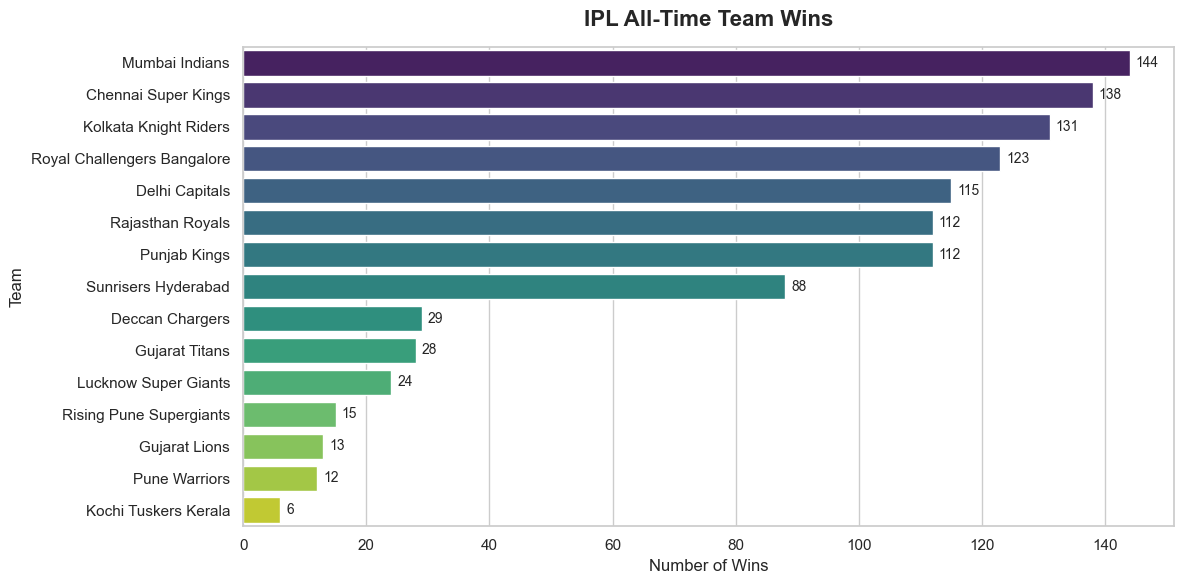

In [22]:

team_wins = matches_clean['winner'].value_counts()
team_wins = team_wins[team_wins.index != 'No Result']

fig, ax = plt.subplots()

sns.barplot(x=team_wins.values, y=team_wins.index,hue=team_wins.index ,palette='viridis', ax=ax,legend=False)


ax.set_title('IPL All-Time Team Wins', fontsize=16, fontweight='bold', pad=15)

ax.set_xlabel('Number of Wins', fontsize=12)

ax.set_ylabel('Team', fontsize=12)


for i, v in enumerate(team_wins.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout() 
plt.savefig('chart1_team_wins.png', dpi=150)
plt.show()

### 💡 Insight
64% of toss winners choose to field first, suggesting teams trust their ability to chase 
targets more than setting them — likely influenced by dew factor in evening matches.

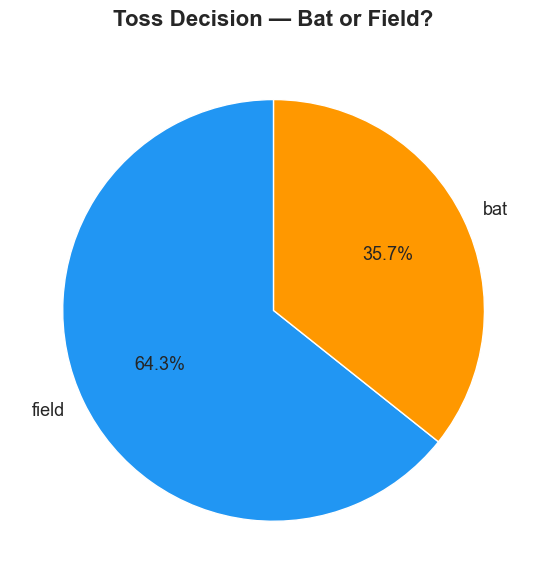

In [33]:
toss_counts = matches_clean['toss_decision'].value_counts()

fig, ax = plt.subplots()


ax.pie(
    toss_counts.values,
    labels=toss_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2196F3', '#FF9800'], 
    textprops={'fontsize': 13}
)

ax.set_title('Toss Decision — Bat or Field?', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart2_toss_decision.png', dpi=150)
plt.show()

### 💡 Insight
Toss winners win the match only 50.6% of the time — barely better than random chance. 
This suggests that toss advantage is largely overstated in cricket commentary.

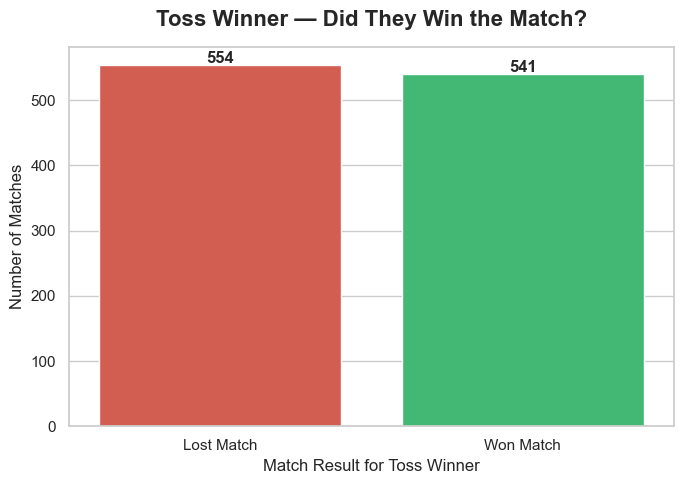

In [34]:
toss_effect = matches_clean['toss_won_match'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    x=['Lost Match', 'Won Match'],
    y=toss_effect.values,
    hue=['Lost Match', 'Won Match'],
    palette=['#e74c3c', '#2ecc71'],
    legend=False,
    ax=ax
)

ax.set_title('Toss Winner — Did They Win the Match?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Match Result for Toss Winner', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)

for i, v in enumerate(toss_effect.values):
    ax.text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_toss_effect.png', dpi=150)
plt.show()

### 💡 Insight
The 2013 season shows a spike of 76 matches due to a double league stage format. 
Seasons consistently settled around 60 matches from 2014 onwards.

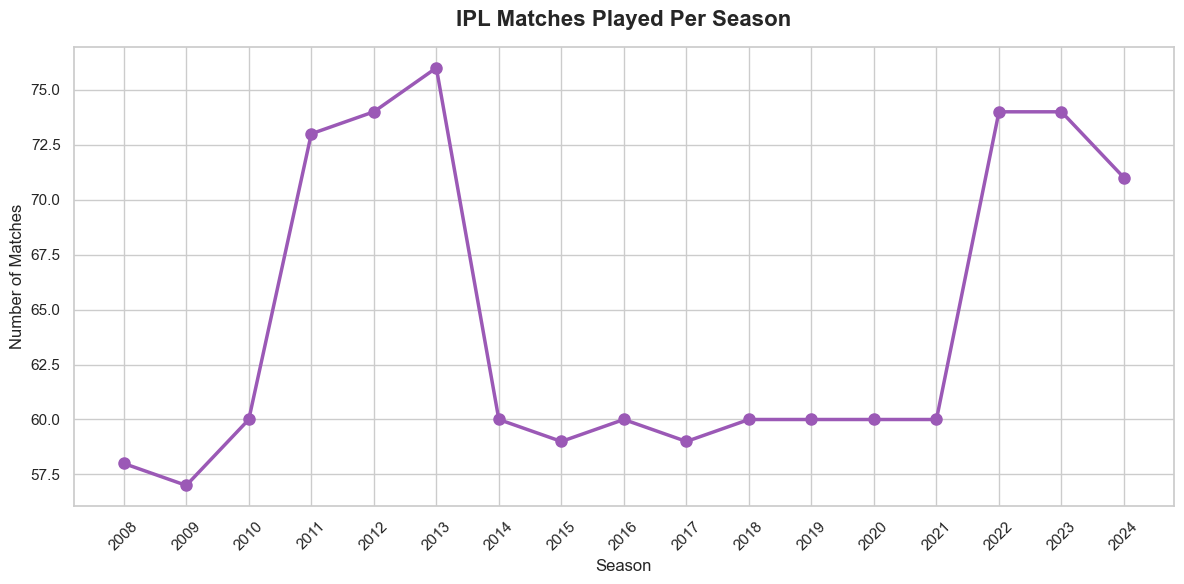

In [36]:
matches_per_season = matches_clean.groupby('season')['id'].count()

fig, ax = plt.subplots()


ax.plot(
    matches_per_season.index,
    matches_per_season.values,
    marker='o',
    linewidth=2.5,
    color='#9b59b6',
    markersize=8
)

ax.set_title('IPL Matches Played Per Season', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)


plt.xticks(matches_per_season.index, rotation=45)

plt.tight_layout()
plt.savefig('chart4_matches_per_season.png', dpi=150)
plt.show()

### 💡 Insight
 Wankhede Stadium and Eden Gardens are the most used venues with 118 matches 
respectively, reflecting Mumbai and Kolkata's central role in IPL history.

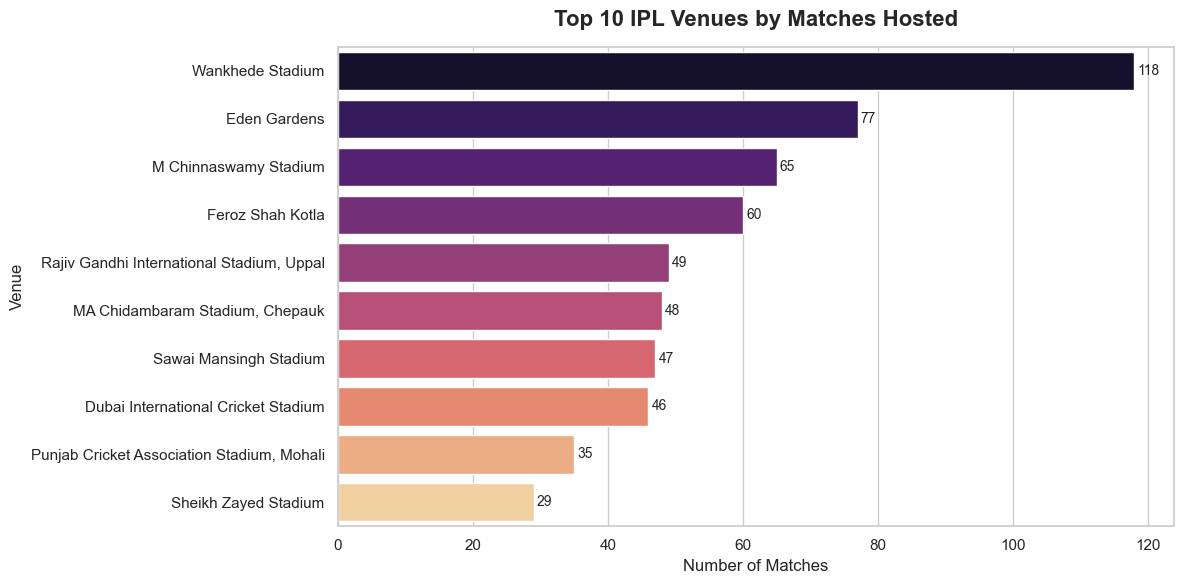

In [26]:
top_venues = matches_clean['venue'].value_counts().head(10)

fig, ax = plt.subplots()

sns.barplot(x=top_venues.values, y=top_venues.index, hue=top_venues.index,palette='magma', ax=ax,legend=False)

ax.set_title('Top 10 IPL Venues by Matches Hosted', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Matches', fontsize=12)
ax.set_ylabel('Venue', fontsize=12)

for i, v in enumerate(top_venues.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart5_top_venues.png', dpi=150)
plt.show()